In [468]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle
from collections import defaultdict
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import json
import os


In [469]:
data_dir = "./data"

processed_dir = os.path.join(data_dir, "processed")
pretest_path = os.path.join(processed_dir, "pretest.csv")
postest_path = os.path.join(processed_dir, "postest.csv")
gameplay_path = os.path.join(processed_dir, "gameplay.ndjson")

metadata_path = os.path.join("../adaptation", "data", "metadata.json")


In [470]:
pretest_df = pd.read_csv(pretest_path, encoding="utf-8")
postest_df = pd.read_csv(postest_path, encoding="utf-8")


In [471]:
with open(metadata_path, "r", encoding="utf-8") as f:
    config = json.load(f)

node_order = []
node_context = {}

# key=int convierte las claves a enteros para ordenar por números
# str -> ["1", "10", "2", "3"]
# int -> [1, 2, 3, 10]
keys = sorted(config.keys(), key=int)

for key in keys:
    item = config[key]

    filename = os.path.basename(item["file"])
    scene = os.path.splitext(filename)[0]
    scene = scene[:1].upper() + scene[1:]

    part = item["object"].split(".")[0]

    node = f"{scene}.{part}"

    node_order.append(node)

    node_context[node] = item.get("context", "")

print(node_order)
print()
print(node_context)


['Scene1Classroom.part2', 'Scene1Bedroom1.computer1', 'Scene1Bedroom1.computer2', 'Scene1Bedroom2.computer', 'Scene2Break.part2', 'Scene3Bedroom.main', 'Scene4Backyard.mainConversation', 'Scene4Garage.phone1', 'Scene4Garage.photo', 'Scene4Bedroom.phone', 'Scene6BedroomRouteA1.phone', 'Scene6LunchRouteB.phone']

{'Scene1Classroom.part2': 'Laura me ha saludado. Ahora me toca responder.', 'Scene1Bedroom1.computer1': '<harasser, Pablo, Lucía> me ha saludado y quiere saber cuánto me gusta ToniVlogs.', 'Scene1Bedroom1.computer2': 'He vuelto al chat. <harasser, Pablo, Lucía> quiere saber desde cuándo sigo a ToniVlogs.', 'Scene1Bedroom2.computer': '<harasser, Pablo, Lucía> me ha dicho que hoy ha estado <harasser, enfermo, enferma>. Me pregunto cómo se encontrará.', 'Scene2Break.part2': 'Paula me ha preguntado si voy a ir a su cumpleaños.', 'Scene3Bedroom.main': '<harasser, Pablo, Lucía> me pregunta cuánto me ha gustado el vídeo.', 'Scene4Backyard.mainConversation': '<harasser, Pablo, Lucía> me

In [472]:
def describe_demographics(pre_df: pd.DataFrame):
	print(f"N: {pre_df['age'].count()}")
	print(f"Mean ± SD: {pre_df['age'].mean():.1f} ± {pre_df['age'].std():.1f}")
	print(f"Median: {pre_df['age'].median():.1f}")
	print(f"Range: {pre_df['age'].min()}-{pre_df['age'].max()}")

	gender = pre_df["gender"].value_counts()
	gender_pct = pre_df["gender"].value_counts(normalize=True) * 100
	display(pd.concat([gender, gender_pct.round(1)], axis=1, keys=["n", "%"]))

	education = pre_df["education_level"].value_counts()
	education_pct = pre_df["education_level"].value_counts(normalize=True) * 100
	display(pd.concat([education, education_pct.round(1)], axis=1, keys=["n", "%"]))
	
	study = pre_df["study_area"].value_counts()
	study_pct = pre_df["study_area"].value_counts(normalize=True) * 100
	display(pd.concat([study, study_pct.round(1)], axis=1, keys=["n", "%"]))


In [473]:
describe_demographics(pretest_df)


N: 2
Mean ± SD: 23.0 ± 1.4
Median: 23.0
Range: 22-24


,n,%
gender,,
Femenino,2,100.0


,n,%
education_level,,
Estudios universitarios,2,100.0


,n,%
study_area,,
Ciencias de la Salud,1,50.0
Ciencias Sociales,1,50.0


In [474]:
dialogue_cols = [
	"dialogue_advance_only",
	"dialogue_predefined_options",
	"dialogue_free_text",
	"dialogue_hybrid",
]

dialogue_diff = (
	pretest_df[["access_code"] + dialogue_cols]
	.merge(
		postest_df[["access_code"] + dialogue_cols],
		on="access_code",
		suffixes=("_pre", "_post"),
	)
)

for col in dialogue_cols:
	dialogue_diff[f"{col}_diff"] = dialogue_diff[f"{col}_post"] - dialogue_diff[f"{col}_pre"]

dialogue_diff = dialogue_diff[["access_code"] + [f"{col}_diff" for col in dialogue_cols]]

display(dialogue_diff)


,access_code,dialogue_advance_only_diff,dialogue_predefined_options_diff,dialogue_free_text_diff,dialogue_hybrid_diff
0,22_tstp,0,0,-1,1
1,22_vezs,0,0,0,0


In [475]:
def plot_dialogue_changes(pre_df: pd.DataFrame, post_df: pd.DataFrame):
	cols = [
		"dialogue_advance_only",
		"dialogue_predefined_options",
		"dialogue_free_text",
		"dialogue_hybrid",
	]
	
	df = pre_df.merge(
		post_df,
		on="access_code",
		suffixes=("_pre", "_post"),
	)

	# Calcular cambios
	changes = pd.DataFrame({
		col: df[f"{col}_post"] - df[f"{col}_pre"]
		for col in cols
	})

	fig, ax = plt.subplots(figsize=(9, 5))

	# Boxplot
	# Línea central -> mediana
	# Caja -> intervalo intercuartílico (Q1-Q3), es decir, el 50% de los datos
	# Bigotes -> rango de los datos
	sns.boxplot(
		data=changes,
		showfliers=False,
		width=0.5,
		color="white",
		ax=ax,
	)

	# Participantes individuales
	sns.swarmplot(
		data=changes,
		size=7,
		ax=ax,
	)

	ax.axhline(0, color="gray", linestyle="--", linewidth=1)

	ax.set_ylabel("Change (Post - Pre)")
	ax.set_xlabel("")
	ax.set_ylim(-4.5, 4.5)

	plt.xticks(rotation=20, ha="right")
	plt.tight_layout()
	plt.show()


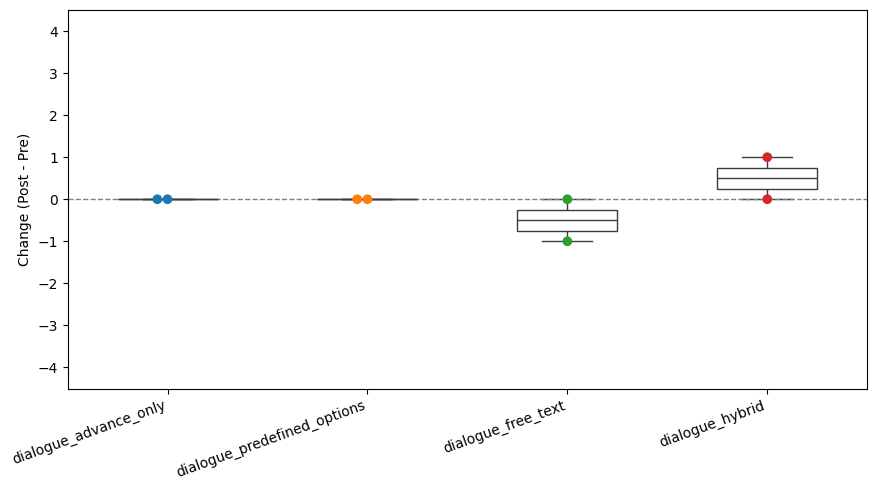

In [476]:
plot_dialogue_changes(pretest_df, postest_df)


In [477]:
# To calculate the SUS score, first sum the score contributions from each item. Each item's
# score contribution will range from 0 to 4. For items 1,3,5,7,and 9 the score contribution is the
# scale position minus 1. For items 2,4,6,8 and 10, the contribution is 5 minus the scale position.
# Multiply the sum of the scores by 2.5 to obtain the overall value of SU.
def calculate_sus(row: pd.Series):
	items = [
		row["sus_use_frequently"],
		row["sus_unnecessarily_complex"],
		row["sus_easy_to_use"],
		row["sus_need_technical_support"],
		row["sus_well_integrated"],
		row["sus_too_much_inconsistency"],
		row["sus_easy_to_learn"],
		row["sus_cumbersome"],
		row["sus_confident"],
		row["sus_need_to_learn"],
	]

	score = 0

	for i, response in enumerate(items, start=1):
		# Items impares
		if i % 2 == 1:
			score += response - 1
		# Item pares
		else:
			score += 5 - response

	return score * 2.5


In [478]:
postest_df["sus_score"] = postest_df.apply(calculate_sus, axis=1)


In [479]:
display(postest_df["sus_score"])


0    60.0
1    85.0
Name: sus_score, dtype: float64

In [480]:
print(f"Mean SUS: {postest_df['sus_score'].mean():.1f}")
print(f"Median SUS: {postest_df['sus_score'].median():.1f}")
print(f"SD: {postest_df['sus_score'].std():.1f}")


Mean SUS: 72.5
Median SUS: 72.5
SD: 17.7


In [481]:
def plot_sus_score(post_df: pd.DataFrame):

	scores = post_df["sus_score"].dropna()

	mean_sus = scores.mean()

	fig, ax = plt.subplots(
		figsize=(11, 3.5),
		dpi=120
	)

	bar_y = 0
	bar_height = 0.10

	regions = [
		(0, 50, "#d73027", "Not acceptable"),
		(50, 70, "#fee08b", "Marginal"),
		(70, 100, "#1a9850", "Acceptable"),
	]

	for start, end, color, label in regions:
		ax.add_patch(
			Rectangle(
				(start, bar_y - bar_height / 2),
				end-start,
				bar_height,
				facecolor=color,
				alpha=0.45,
				edgecolor="none"
			)
		)

		ax.text(
			(start+end)/2,
			0.10,
			label,
			ha="center",
			fontsize=12,
			fontweight="bold"
		)


	# Separadores
	for x in [50, 70]:
		ax.vlines(
			x,
			-bar_height/2,
			bar_height/2,
			color="white",
			linewidth=2
		)

	# Participantes
	ax.scatter(
		scores,
		np.zeros(len(scores)),
		s=75,
		facecolor="white",
		edgecolor="#222222",
		linewidth=1,
		alpha=0.9,
		zorder=3,
		label=f"Participants (n={len(scores)})"
	)

	# Media
	ax.scatter(
		mean_sus,
		0,
		marker="D",
		s=130,
		color="#111111",
		zorder=4,
		label=f"Mean = {mean_sus:.1f}"
	)

	# Escala inferior
	scale_y = -0.08

	ax.hlines(
		scale_y,
		0,
		100,
		color="black",
		linewidth=1
	)

	for x in range(0, 101, 10):
		ax.vlines(
			x,
			scale_y,
			scale_y+0.03,
			color="black",
			linewidth=1
		)

		ax.text(
			x,
			scale_y-0.03,
			str(x),
			ha="center",
			fontsize=11
		)
	
	ax.set_xlim(0,100)
	ax.set_ylim(-0.20,0.20)

	ax.set_yticks([])
	ax.set_xticks([])

	ax.set_title(
		"System Usability Scale (SUS)",
		fontsize=14,
		fontweight="bold",
		pad=5
	)

	for spine in ax.spines.values():
		spine.set_visible(False)

	ax.legend(
		loc="center left",
		bbox_to_anchor=(1.01,0.5),
		frameon=False,
		fontsize=13
	)

	plt.tight_layout()

	plt.show()


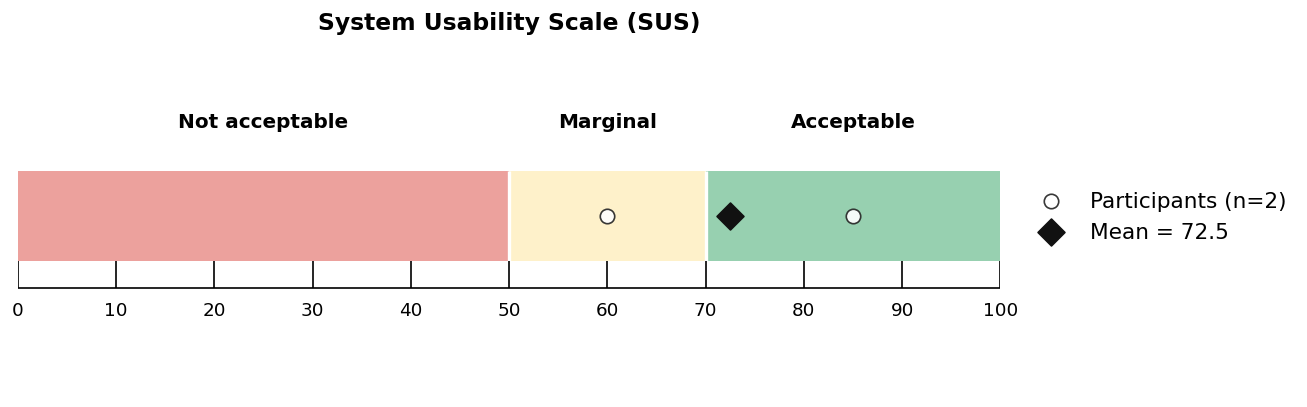

In [482]:
# https://www.tandfonline.com/doi/abs/10.1080/10447310802205776
# https://measuringu.com/interpret-sus-score/
# https://measuringu.com/sus/
# https://uifrommars.com/como-medir-usabilidad-que-es-sus/
plot_sus_score(postest_df)


In [483]:
def plot_likert_stacked(post_df: pd.DataFrame, cols: list[str], title: str = "Likert evaluation"):
	likert_values = [1, 2, 3, 4, 5]

	colors = [
		"#d73027",
		"#fc8d59",
		"#fee08b",
		"#91cf60",
		"#1a9850",
	]

	counts = pd.DataFrame()

	for col in cols:
		counts[col] = post_df[col].value_counts().reindex(likert_values, fill_value=0)

	counts = counts.T

	fig, ax = plt.subplots(figsize=(9, 4))

	left = [0] * len(counts)

	for value, color in zip(likert_values, colors):
		values = counts[value].tolist()

		ax.barh(
			counts.index,
			values,
			left=left,
			label=str(value),
			color=color,
		)

		for i in range(len(left)):
			left[i] += values[i]

	ax.set_xlabel("Number of participants")
	ax.set_xlim(0, len(post_df))
	ax.xaxis.set_major_locator(MaxNLocator(integer=True))

	ax.legend(
		title="Likert response",
		bbox_to_anchor=(1.05, 1),
		loc="upper left",
	)

	ax.set_title(title)

	plt.tight_layout()
	plt.show()


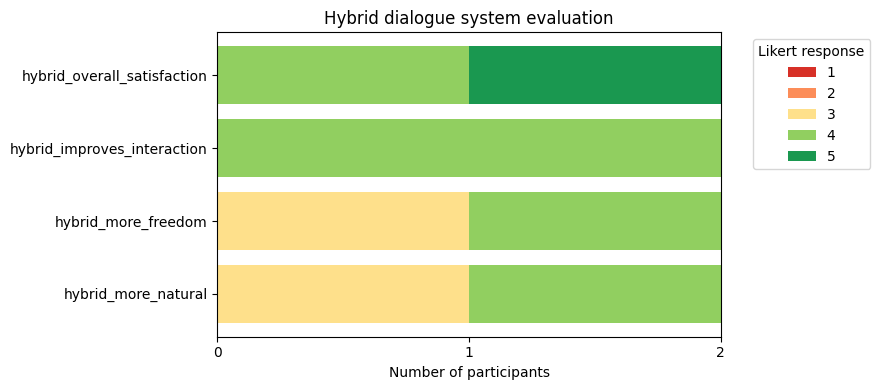

In [484]:
cols = [
	"hybrid_more_natural",
	"hybrid_more_freedom",
	"hybrid_improves_interaction",
	"hybrid_overall_satisfaction",
]

plot_likert_stacked(postest_df, cols, "Hybrid dialogue system evaluation")


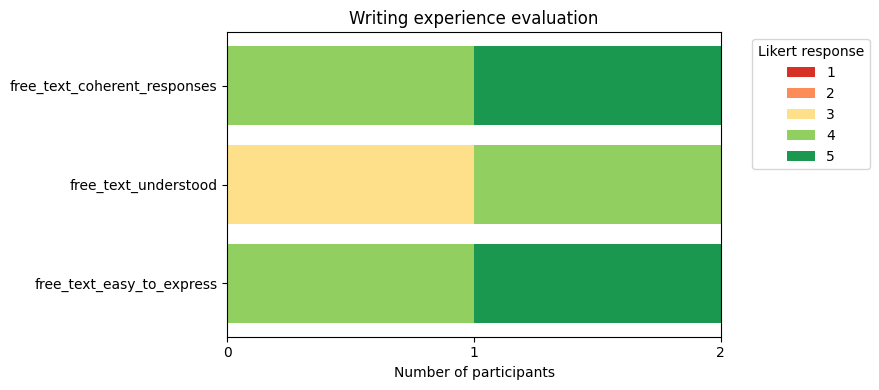

In [485]:
cols = [
	"free_text_easy_to_express",
	"free_text_understood",
	"free_text_coherent_responses"
]

plot_likert_stacked(postest_df, cols, "Writing experience evaluation")


In [486]:
with open(gameplay_path, "r", encoding="utf-8") as f:
	records = [json.loads(line) for line in f]

print(f"Original records: {len(records)}")


Original records: 103


In [487]:
NODE_EXTENSION = "https://w3id.org/xapi/seriousgame/extensions/Node"

START_EVENT = "https://w3id.org/xapi/lab/activity-types/story-node/ThoughtBoxStart"
END_EVENT = "https://w3id.org/xapi/lab/activity-types/story-node/ThoughtBoxEnd"

# Comienzos para cada (usuario, nodo)
pending_starts = defaultdict(list)

# Duraciones para cada (usuario, nodo)
durations = defaultdict(list)

matches = defaultdict(list)

for record in records:
	event = record.get("object", {}).get("id")
	user = record.get("actor", {}).get("account", {}).get("name")
	node = record.get("result", {}).get("extensions", {}).get(NODE_EXTENSION)

	node = ".".join(node.split(".")[:2]) if node is not None else None

	timestamp = datetime.fromisoformat(record["timestamp"].replace("Z", "+00:00"))

	key = (user, node)

	if event == START_EVENT:
		pending_starts[key].append(timestamp)

	elif event == END_EVENT:
		if pending_starts[key]:
			start = pending_starts[key].pop(0)
			duration = (timestamp - start).total_seconds()

			durations[key].append(duration)
			matches[key].append((start, timestamp, duration))

print("Average ThoughtBox duration per user/node:")
for (user, node), values in durations.items():
	avg = sum(values) / len(values)
	print(f"{user:10} | {node:40} | count={len(values)}) | avg={avg:.4f} s")

print("\nLong durations (>60 s):")
for (user, node), pairs in matches.items():
	for start, end, duration in pairs:
		if duration > 60:
			print(
				f"User : {user}\n"
				f"Node : {node}\n"
				f"Start: {start.isoformat()}\n"
				f"End  : {end.isoformat()}\n"
				f"Δt   : {duration:.4f} s\n"
			)


Average ThoughtBox duration per user/node:
vezs       | Scene1Classroom.part2                    | count=2) | avg=0.0020 s
vezs       | Computer.computer1                       | count=1) | avg=0.0020 s
vezs       | Computer.computer2                       | count=1) | avg=0.0010 s
vezs       | Computer.computer                        | count=3) | avg=0.0010 s
vezs       | Scene2Break.part2                        | count=1) | avg=0.0020 s
vezs       | Scene3Bedroom.main                       | count=3) | avg=0.0017 s
vezs       | Scene4Backyard.mainConversation          | count=1) | avg=0.0010 s
vezs       | Scene4Garage.phone1                      | count=1) | avg=0.0010 s
vezs       | Scene4Garage.photo                       | count=2) | avg=0.0015 s
vezs       | Scene4Bedroom.phone                      | count=2) | avg=0.0020 s
vezs       | Scene6LunchRouteB.phone                  | count=3) | avg=0.0020 s
tstp       | Scene1Classroom.part2                    | count=1) | avg=0.0030

In [488]:
node_user_avgs = defaultdict(list)

for (user, node), values in durations.items():
	node_user_avgs[node].append(sum(values) / len(values))

print("\nAverage ThoughtBox duration per node (averaging users):")

available_nodes = list(node_user_avgs.keys())

nodes = []
labels = []
averages = []

for expected in node_order:
    # Nombre
    if expected in available_nodes:
        match = expected

    else:
        # Si no está el nombre exacto, buscar por la segunda parte
        expected_part = expected.split(".", 1)[1]

        match = None

        for node in available_nodes:
            if "." not in node:
                continue

            node_part = node.split(".", 1)[1]

            if node_part == expected_part:
                match = node
                break

    if match is None:
        continue

    user_avgs = node_user_avgs[match]
    avg = sum(user_avgs) / len(user_avgs)

    print(
        f"{expected:40} | "
        f"users={len(user_avgs):2d} | "
        f"avg={avg:.4f} s"
    )

    nodes.append(match)
    labels.append(expected)
    averages.append(avg)



Average ThoughtBox duration per node (averaging users):
Scene1Classroom.part2                    | users= 2 | avg=0.0025 s
Scene1Bedroom1.computer1                 | users= 2 | avg=0.0020 s
Scene1Bedroom1.computer2                 | users= 2 | avg=0.0010 s
Scene1Bedroom2.computer                  | users= 2 | avg=0.0018 s
Scene2Break.part2                        | users= 2 | avg=0.0020 s
Scene3Bedroom.main                       | users= 2 | avg=0.0018 s
Scene4Backyard.mainConversation          | users= 2 | avg=0.0025 s
Scene4Garage.phone1                      | users= 1 | avg=0.0010 s
Scene4Garage.photo                       | users= 2 | avg=0.0013 s
Scene4Bedroom.phone                      | users= 2 | avg=0.0020 s
Scene6BedroomRouteA1.phone               | users= 1 | avg=0.0020 s
Scene6LunchRouteB.phone                  | users= 1 | avg=0.0020 s


In [489]:
print(len(nodes))


12


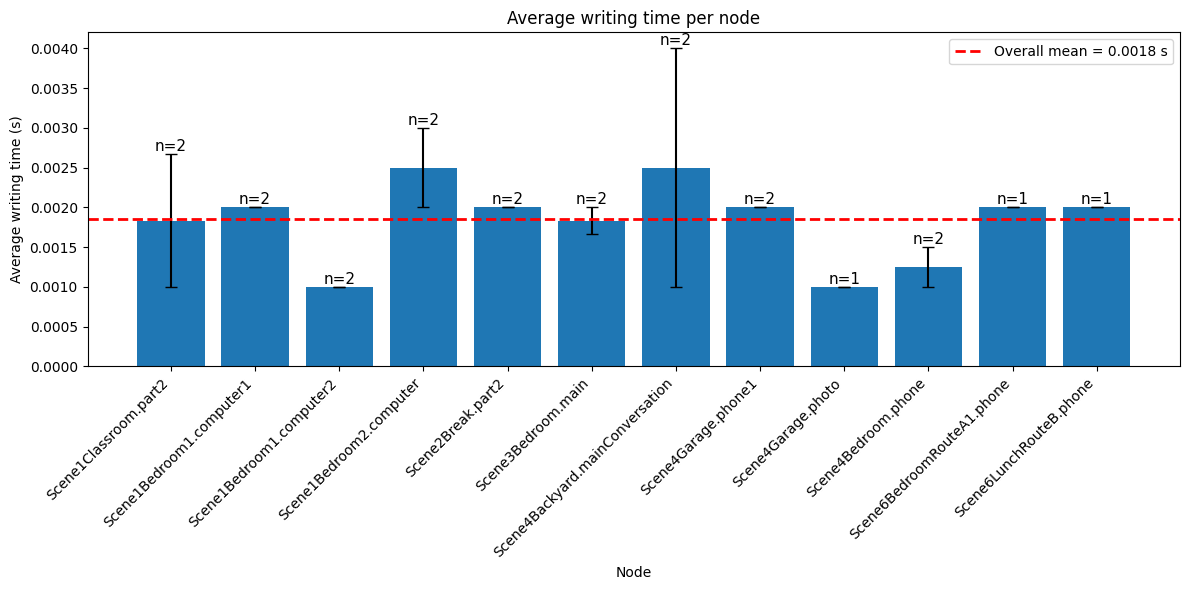

In [490]:
items = sorted(node_user_avgs.items())

means = []
sems = []
counts = []

for node, user_avgs in items:
	n_users = len(user_avgs)

	# Media de los usuarios para el nodo
	mean = np.mean(user_avgs)
	# Standard Error of the Mean (SEM)
	sem = np.std(user_avgs, ddof=1) / np.sqrt(n_users) if len(user_avgs) > 1 else 0
	
	means.append(mean)
	sems.append(sem)
	counts.append(n_users)

# Media ponderada en función del número de usuarios
overall_mean = np.average(means, weights=counts)

plt.figure(figsize=(12, 6))

bars = plt.bar(
	labels, 
	means, 
	yerr=sems, 
	capsize=4
)

plt.axhline(
	overall_mean,
	color="red",
	linestyle="--",
	linewidth=2,
	label=f"Overall mean = {overall_mean:.4f} s",
)

# Número de usuarios encima de cada barra
for bar, n_users, sem in zip(bars, counts, sems):
	plt.text(
		bar.get_x() + bar.get_width() / 2,
		bar.get_height() + sem,
		f"n={n_users}",
		ha="center",
		va="bottom",
		fontsize=11,
	)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Node")
plt.ylabel("Average writing time (s)")
plt.title("Average writing time per node")
plt.legend()
plt.tight_layout()
plt.show()


In [491]:
DIALOG_PREFIX = "https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/"
MATCHING_TEXT = "https://w3id.org/xapi/seriousgame/extensions/MatchingText"
METHOD = "https://w3id.org/xapi/seriousgame/extensions/Method"

MAX_ATTEMPTS = 3

attempts = defaultdict(int)
finished = set()

results = []

for record in records:
	object_id = record.get("object", {}).get("id", "")
	extensions = record.get("result", {}).get("extensions", {})
	
	if object_id.startswith(DIALOG_PREFIX) and MATCHING_TEXT in extensions:
		user = record["actor"]["account"]["name"]
		success = record.get("result", {}).get("success", False)
		method = extensions.get(METHOD, "unknown")

		key = (user, object_id)
		
		if key not in finished:
			attempts[key] += 1

			# Éxito antes del máximo
			if success:
				results.append({
					"user": user,
					"node": object_id,
					"method": method,
					"attempts": attempts[key],
					"success": True
				})
				finished.add(key)

			# Se han agotado los intentos sin éxito
			elif attempts[key] == MAX_ATTEMPTS:
				results.append({
					"user": user,
					"node": object_id,
					"method": method,
					"attempts": MAX_ATTEMPTS + 1,
					"success": False
				})
				finished.add(key)
			

In [492]:
for result in results:
    print(
        f"{result["user"]} | "
        f"{result["node"]} | "
        f"{result["method"]} | "
        f"{result["attempts"]} | "
        f"{result["success"]}"
    )


vezs | https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/Scene1Classroom.part2.thanks_similarity | lstm | 2 | True
vezs | https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/Computer.computer1.choices_similarity | lstm | 1 | True
vezs | https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/Computer.computer2.root | lstm | 1 | True
vezs | https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/Computer.computer.choices2_similarity | lstm | 4 | False
vezs | https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/Scene2Break.part2.choice_similarity | lstm | 1 | True
vezs | https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/Scene3Bedroom.main.choices_similarity | lstm | 3 | True
vezs | https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/Scene4Backyard.mainConversation.choices_similarity | lstm | 1 | True
vezs | https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/Scene4Garage.phone1.root | lstm | 1 | True
vezs | https:

In [493]:
df = pd.DataFrame(results)

df["node"] = df["node"].apply(lambda node: ".".join(node.split("/")[-1].split(".")[:2]))

summary = (
    df.groupby(["node", "method"], as_index=False)
    .agg(
        success_rate=(
            "attempts",
            lambda x: (x <= MAX_ATTEMPTS).mean() * 100
        ),
        mean_attempts_success=(
            "attempts",
            lambda x: x[x <= MAX_ATTEMPTS].mean()
        ),
        mean_attempts=(
            "attempts",
            "mean"
        )
    )
)

display(summary)


,node,method,success_rate,mean_attempts_success,mean_attempts
0,Computer.computer,lstm,50.0,3.0,3.5
1,Computer.computer1,lstm,100.0,1.0,1.0
2,Computer.computer2,lstm,100.0,1.0,1.0
3,Scene1Classroom.part2,lstm,100.0,1.5,1.5
4,Scene2Break.part2,lstm,100.0,1.0,1.0
5,Scene3Bedroom.main,lstm,100.0,2.5,2.5
6,Scene4Backyard.mainConversation,lstm,100.0,1.0,1.0
7,Scene4Bedroom.phone,lstm,100.0,2.0,2.0
8,Scene4Garage.phone1,lstm,100.0,1.0,1.0
9,Scene4Garage.photo,lstm,100.0,1.5,1.5


In [494]:
summary_nodes = summary["node"].unique()

ordered_nodes = []

for expected in node_order:
    # Nombre exacto
    if expected in summary_nodes:
        ordered_nodes.append((expected, expected))
        continue

    # Si no esta el nombre exacto, buscar por la segunda parte
    expected_part = expected.split(".", 1)[1]

    for node in summary_nodes:
        node_part = node.split(".", 1)[1]

        if node_part == expected_part:
            match = node
            break

    if match is not None:
        ordered_nodes.append((match, expected))

# Separar los nodos de las etiquetas
nodes = [n for n, _ in ordered_nodes]
labels = [l for _, l in ordered_nodes]

print(nodes)
print()
print(labels)


['Scene1Classroom.part2', 'Computer.computer1', 'Computer.computer2', 'Computer.computer', 'Scene2Break.part2', 'Scene3Bedroom.main', 'Scene4Backyard.mainConversation', 'Scene4Garage.phone1', 'Scene4Garage.photo', 'Scene4Bedroom.phone', 'Scene6BedroomRouteA1.phone', 'Scene6LunchRouteB.phone']

['Scene1Classroom.part2', 'Scene1Bedroom1.computer1', 'Scene1Bedroom1.computer2', 'Scene1Bedroom2.computer', 'Scene2Break.part2', 'Scene3Bedroom.main', 'Scene4Backyard.mainConversation', 'Scene4Garage.phone1', 'Scene4Garage.photo', 'Scene4Bedroom.phone', 'Scene6BedroomRouteA1.phone', 'Scene6LunchRouteB.phone']


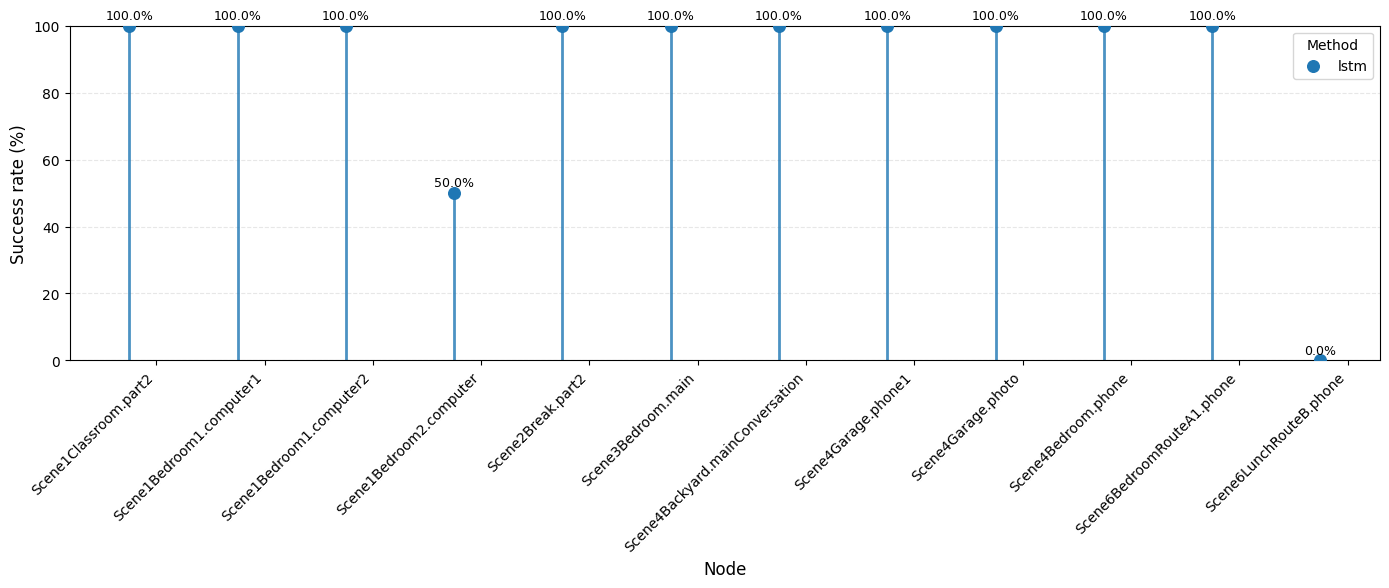

In [495]:
methods = sorted(summary["method"].unique())

x = np.arange(len(nodes))
offsets = np.linspace(-0.25, 0.25, len(methods))

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(methods):
    data = summary[summary["method"] == method]

    values = []
    for node in nodes:
        row = data[data["node"] == node]
        values.append(row["success_rate"].iloc[0])

    xpos = x + offsets[i]

    # Palo
    ax.vlines(
        xpos,
        0,
        values,
        color=colors[i],
        linewidth=2,
        alpha=0.8
    )

    # Punto
    ax.scatter(
        xpos,
        values,
        s=70,
        color=colors[i],
        label=method,
        zorder=3
    )

    # Etiqueta
    for xi, yi in zip(xpos, values):
        ax.text(
            xi,
            yi + 1,
            f"{yi:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_ylim(0, 100)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_ylabel("Success rate (%)", fontsize=12)
ax.set_xlabel("Node", fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.legend(title="Method")

plt.tight_layout()
plt.show()


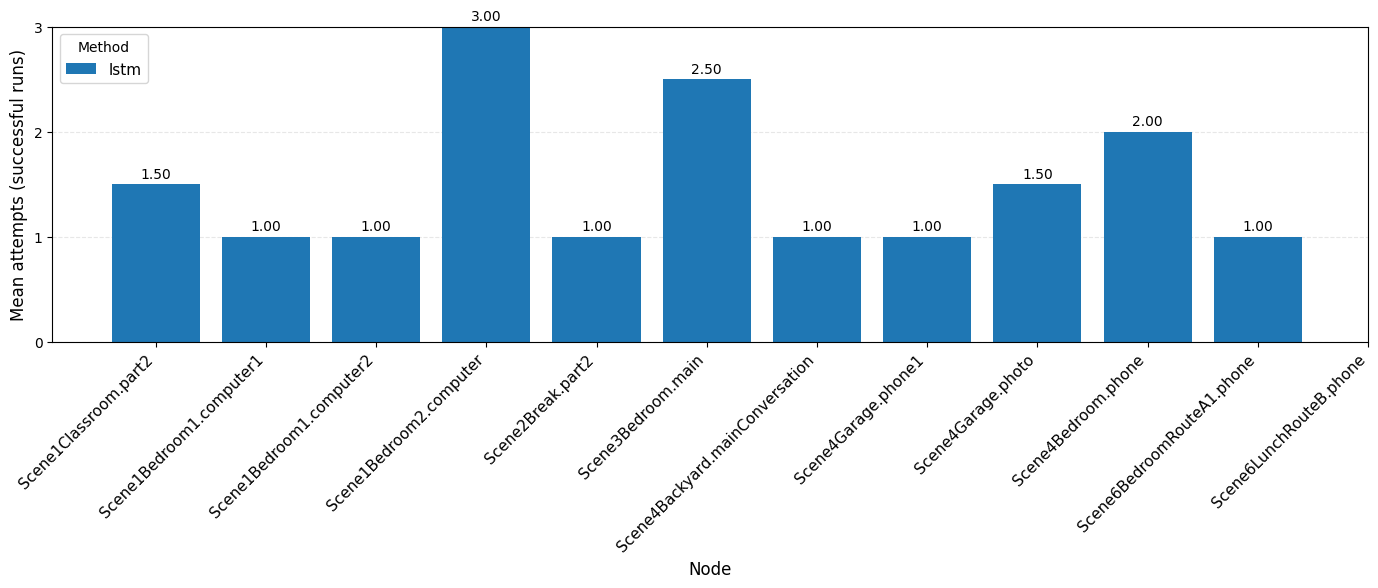

In [496]:
methods = sorted(summary["method"].unique())

x = np.arange(len(nodes))
width = 0.8 / len(methods)

fig, ax = plt.subplots(figsize=(14, 6))

for i, method in enumerate(methods):
    data = summary[summary["method"] == method]
    values = []

    for node in nodes:
        row = data[data["node"] == node]
        values.append(
            row["mean_attempts_success"].iloc[0]
            if not row.empty else np.nan
        )

    bars = ax.bar(
        x + i * width,
        values,
        width,
        label=method
    )

    # Mostrar el valor encima de cada barra
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.03,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=10
            )

# El eje ya refleja el máximo permitido (3 intentos)
ax.set_ylim(0, MAX_ATTEMPTS)
ax.set_yticks(np.arange(0, MAX_ATTEMPTS + 1, 1))

# Rejilla horizontal para facilitar la comparación
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.set_xticks(x + width * (len(methods) - 1) / 2)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_ylabel("Mean attempts (successful runs)", fontsize=12)
ax.set_xlabel("Node", fontsize=12)

ax.legend(title="Method", fontsize=11)
ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.show()


In [497]:
node_labels = dict(zip(nodes, labels))

print(node_labels)


{'Scene1Classroom.part2': 'Scene1Classroom.part2', 'Computer.computer1': 'Scene1Bedroom1.computer1', 'Computer.computer2': 'Scene1Bedroom1.computer2', 'Computer.computer': 'Scene1Bedroom2.computer', 'Scene2Break.part2': 'Scene2Break.part2', 'Scene3Bedroom.main': 'Scene3Bedroom.main', 'Scene4Backyard.mainConversation': 'Scene4Backyard.mainConversation', 'Scene4Garage.phone1': 'Scene4Garage.phone1', 'Scene4Garage.photo': 'Scene4Garage.photo', 'Scene4Bedroom.phone': 'Scene4Bedroom.phone', 'Scene6BedroomRouteA1.phone': 'Scene6BedroomRouteA1.phone', 'Scene6LunchRouteB.phone': 'Scene6LunchRouteB.phone'}


In [498]:
THRESHOLD_EXTENSION = "https://w3id.org/xapi/seriousgame/extensions/Threshold"
BRANCH_EXTENSION = "https://w3id.org/xapi/seriousgame/extensions/Branch"

failed_attempts = defaultdict(list)

for record in records:
    node = record.get("object", {}).get("id", "")
    extensions = record.get("result", {}).get("extensions", {})

    if node.startswith(DIALOG_PREFIX) and MATCHING_TEXT in extensions:
        user = record["actor"]["account"]["name"]
        result = record.get("result", {})

        success = result.get("success", False)
        score = result.get("score", {}).get("scaled", None)
        threshold = extensions.get(THRESHOLD_EXTENSION, None)

        method = extensions.get(METHOD, "unknown")
        branch = extensions.get(BRANCH_EXTENSION)

        text = result.get("response", "")
        matching_text = extensions.get(MATCHING_TEXT, "")

        node_prefix = ".".join(node.split("/")[-1].split(".")[:2])
        node = node_labels[node_prefix]

        # Guardar todos los intentos fallidos
        if not success:
            failed_attempts[node].append({
                "user": user,
                "text": text,
                "matching_text": matching_text,
                "branch": branch,
                "method": method,
                "score": score,
                "threshold": threshold,
                "difference": threshold - score
            })

print(failed_attempts)


defaultdict(<class 'list'>, {'Scene1Classroom.part2': [{'user': 'vezs', 'text': 'burnos dias ', 'matching_text': 'Holaaa buenas, soy cris, acabo de llegar y estoy todavía un poco perdido, y tú?', 'branch': 'friendly', 'method': 'lstm', 'score': 0.31477296352386475, 'threshold': 0.52, 'difference': 0.20522703647613527}], 'Scene1Bedroom2.computer': [{'user': 'vezs', 'text': 'cuidate', 'matching_text': 'Ay pobre, dormiste mal o algo?', 'branch': 'ask2', 'method': 'lstm', 'score': 0.11603830009698868, 'threshold': 0.52, 'difference': 0.40396169990301134}, {'user': 'vezs', 'text': 'recuperate', 'matching_text': 'Ay pobre, dormiste mal o algo?', 'branch': 'ask2', 'method': 'lstm', 'score': 0.5153499841690063, 'threshold': 0.52, 'difference': 0.00465001583099367}, {'user': 'vezs', 'text': 'me alegro que estes bien ', 'matching_text': 'Ahh, me alegra que estés mejor', 'branch': 'ask2', 'method': 'lstm', 'score': 0.49400001764297485, 'threshold': 0.52, 'difference': 0.025999982357025164}, {'use

In [499]:
for node, failures in failed_attempts.items():
    print("\n" + "=" * 80)
    print(f"NODE: {node}")
    print(f"CONTEXT: {node_context.get(node, '')}")
    print("=" * 80)

    for i, failure in enumerate(failures):
        print(f"\nAttempt {i}")
        print(f"User: {failure['user']}")
        print(f"Response: {failure['text']}")
        print(f"Expected: {failure['matching_text']}")
        print(
            f"Score: {failure['score']:.4f} | "
            f"Threshold: {failure['threshold']:.4f} | "
            f"Δ: {failure['difference']:.4f}"
        )
        


NODE: Scene1Classroom.part2
CONTEXT: Laura me ha saludado. Ahora me toca responder.

Attempt 0
User: vezs
Response: burnos dias 
Expected: Holaaa buenas, soy cris, acabo de llegar y estoy todavía un poco perdido, y tú?
Score: 0.3148 | Threshold: 0.5200 | Δ: 0.2052

NODE: Scene1Bedroom2.computer
CONTEXT: <harasser, Pablo, Lucía> me ha dicho que hoy ha estado <harasser, enfermo, enferma>. Me pregunto cómo se encontrará.

Attempt 0
User: vezs
Response: cuidate
Expected: Ay pobre, dormiste mal o algo?
Score: 0.1160 | Threshold: 0.5200 | Δ: 0.4040

Attempt 1
User: vezs
Response: recuperate
Expected: Ay pobre, dormiste mal o algo?
Score: 0.5153 | Threshold: 0.5200 | Δ: 0.0047

Attempt 2
User: vezs
Response: me alegro que estes bien 
Expected: Ahh, me alegra que estés mejor
Score: 0.4940 | Threshold: 0.5200 | Δ: 0.0260

Attempt 3
User: tstp
Response: mejorate
Expected: Espero que te mejores pronto. Si necesitas ayuda con la tarea, me dices.
Score: 0.2842 | Threshold: 0.5200 | Δ: 0.2358

Atte

In [500]:
rows = []

for node, failures in failed_attempts.items():
    for failure in failures:
        rows.append({
            "node": node,
            "context": node_context[node],
            "method": failure["method"],
            "branch": failure["branch"],
            "response": failure["text"],
            "matching_text": failure["matching_text"],
            "score": failure["score"],
            "threshold": failure["threshold"],
            "difference": failure["difference"]
        })

df = pd.DataFrame(rows)

df.to_csv("failed_cases.csv", index=False)
